In [1]:
!nvidia-smi

Sun Oct  4 13:28:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  GRID V100DX-32C                On  |   00000000:06:00.0 Off |                    0 |
| N/A   N/A    P0            N/A  /  N/A  |       1MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, sys

nb_path = './'
sys.path.insert(0,nb_path)

In [3]:
# Install packages
!pip install --no-cache-dir shtns
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip install pyshtools

Defaulting to user installation because normal site-packages is not writeable


In [6]:
!pip install sympy

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import csv
import time
from datetime import datetime
import numpy as np
import pandas as pd
import scipy
from scipy.optimize._numdiff import approx_derivative
import matplotlib.pyplot as plt

import torch
import shtns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

[SHTns 3.7.5] built Jun 13 2026, 12:02:04, id: avx512,ishioka


In [8]:
from math import sqrt, factorial, pi, log
import cmath
from sympy.physics.wigner import wigner_3j
from pyshtools.legendre import PlmIndex, PlmSchmidt_d1
from pyshtools import SHMagCoeffs

/storage/fi_gt_foldmag_26/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import settings

# Main utility functions

### Galerkin basis functions and derivatives

In [10]:
# ============================================================
# Jacobi polynomials (vectorized, no tensor recreation)
# ============================================================
def jacobi_recurrence_for_GPU(power, alpha, beta, x):
    if power < 0:
        return torch.zeros_like(x)

    J0 = torch.ones_like(x)
    if power == 0:
        return J0

    J1 = 0.5 * (alpha + beta + 2) * x + 0.5 * (alpha - beta)
    if power == 1:
        return J1

    J_prev = J0
    J_curr = J1

    for n in range(2, power + 1):
        an = (2*(n-1)+alpha+beta+1)*(2*(n-1)+alpha+beta+2) / (2*n*(n+alpha+beta))
        bn = (beta**2 - alpha**2)*(2*(n-1)+alpha+beta+1) / (2*n*(n+alpha+beta)*(2*(n-1)+alpha+beta))
        cn = (n+1+alpha)*(n+1+beta)*(2*(n+1)+alpha+beta+2) / ((n+2)*(n+alpha+beta+2)*(2*(n+1)+alpha+beta))

        J_next = (an * x - bn) * J_curr - cn * J_prev
        J_prev = J_curr
        J_curr = J_next

    return J_curr


# ============================================================
# Psi computation (vectorized)
# ============================================================
def compute_all_Psi(r, degree, band_nr, mu):
    r = r.to(device)
    z = 2 * r**2 - 1

    alpha = 2
    beta = degree + 0.5

    Psi_vals = []

    for k in range(1, band_nr):
        if k == 1:
            Psi = r**degree * (-mu*degree - 2*mu - 1 + r**2 * mu*degree + r**2)
        elif k == 2:
            Psi = r**degree * (
                6*mu*degree**2 + 27*mu*degree + 27*mu + 2*degree + 3
                - 12*r**2*degree**2*mu - 4*r**2*degree
                - 58*r**2*mu*degree - 10*r**2 - 70*r**2*mu
                + 6*r**4*degree**2*mu + 2*r**4*degree
                + 31*r**4*mu*degree + 35*r**4*mu + 7*r**4
            )
        else:
            c = torch.zeros(4, device=device)

            c[0] = (2*degree - 3 + 4*k)*(2*degree + 5 + 2*k)*(2*degree - 1 + 4*k)*(2*k*mu*degree - mu*degree + 1 + 2*k**2*mu - mu - k*mu)*(2*degree + 3 + 2*k)
            c[1] = -(2*degree - 3 + 4*k)*(2*degree + 3 + 2*k)*(2*degree + 3 + 4*k)*(2*degree + 1 + 2*k)*(-mu*degree + 6*k*mu*degree + 3 + k*mu + 6*k**2*mu + 2*mu)
            c[2] = (2*degree - 1 + 4*k)*(2*degree + 5 + 4*k)*(2*degree + 1 + 2*k)*(-1 + 2*degree + 2*k)*(6*k*mu*degree + mu*degree + 5*k*mu + 3 + 3*mu + 6*k**2*mu)
            c[3] = -(2*degree - 3 + 2*k)*(2*degree + 5 + 4*k)*(2*degree + 3 + 4*k)*(-1 + 2*degree + 2*k)*(2*k*mu*degree + mu*degree + 3*k*mu + 2*k**2*mu + 1)

            jacobi_vec = torch.stack([
                jacobi_recurrence_for_GPU(k, alpha, beta, z),
                jacobi_recurrence_for_GPU(k-1, alpha, beta, z),
                jacobi_recurrence_for_GPU(k-2, alpha, beta, z),
                jacobi_recurrence_for_GPU(k-3, alpha, beta, z)
            ])

            Psi = r**degree * torch.matmul(c, jacobi_vec)

        #TODO: replace .append in the below line w. torch.cat
        Psi_vals.append(Psi)

    return torch.stack(Psi_vals)  # shape: [band_nr-1, N]

# ============================================================
# Produce derivatives of the basis functions
# ============================================================
def d_psi_d_r(r, n, k, mu):
    '''
    Returns the radial derivative of the galerkin polynomial repr. Psi(r)
    :param r: observation radius
    :param n: SH degree of the representation
    :param k: polynomial degree of the representation
    :param mu: degree-based multiplier
    :return: d(Psi(r))/dr
    '''
    r = r.to(device)
    alpha = 2
    beta = n + 1 / 2
    z = 2 * r**2 - 1
    
    d_psi_dr_vec = []
    for k in range(1, band_nr):
        if k == 1:
            d_psi_dr = n * r ** (n-1) * (-mu * n - 2 * mu - 1 + r ** 2 * mu * n + r ** 2) + \
                     r ** n * (-mu * n - 2 * mu - 1 + 2 * r * mu * n + 2 * r)
        elif k == 2:
            d_psi_dr = n * r ** (n-1) * (6 * mu * n ** 2 + 27 * mu * n + 27 * mu + 2 * n + 3 - 12 * r ** 2 * n ** 2 * mu - 4 * r ** 2 * n - 58 * r ** 2 * mu * n - 10 * r ** 2 - 70 * r ** 2 * mu + 6 * r ** 4 * n ** 2 * mu + 2 * r ** 4 * n + 31 * r ** 4 * mu * n + 35 * r ** 4 * mu + 7 * r ** 4) + \
                    r ** n * (6 * mu * n ** 2 + 27 * mu * n + 27 * mu + 2 * n + 3 - 12 * 2 * r * n ** 2 * mu - 4 * 2 * r * n - 58 * 2 * r * mu * n - 10 * 2 * r - 70 * 2 * r * mu + 6 * 4 * r**3 * n ** 2 * mu + 2 * 4 * r ** 3 * n + 31 * 4 * r ** 3 * mu * n + 35 * 4 * r ** 3 * mu + 7 * 4 * r ** 3)

        c = torch.zeros(4, device=device)
        c[0] = (2 * n - 3 + 4 * k) * (2 * n + 5 + 2 * k) * (2 * n - 1 + 4 * k) * (
                    2 * k * mu * n - mu * n + 1 + 2 * k ** 2 * mu - mu - k * mu) * (2 * n + 3 + 2 * k)
        c[1] = -(2 * n - 3 + 4 * k) * (2 * n + 3 + 2 * k) * (2 * n + 3 + 4 * k) * (2 * n + 1 + 2 * k) * (
                    -mu * n + 6 * k * mu * n + 3 + k * mu + 6 * k ** 2 * mu + 2 * mu)
        c[2] = (2 * n - 1 + 4 * k) * (2 * n + 5 + 4 * k) * (2 * n + 1 + 2 * k) * (-1 + 2 * n + 2 * k) * (
                    6 * k * mu * n + mu * n + 5 * k * mu + 3 + 3 * mu + 6 * k ** 2 * mu)
        c[3] = -(2 * n - 3 + 2 * k) * (2 * n + 5 + 4 * k) * (2 * n + 3 + 4 * k) * (-1 + 2 * n + 2 * k) * (
                    2 * k * mu * n + mu * n + 3 * k * mu + 2 * k ** 2 * mu + 1)

        jacobi_vec = np.zeros([4,1])
        jacobi_vec = torch.stack([
                    2 * r * (k + alpha + beta + 1) * jacobi_recurrence_for_GPU(k, alpha, beta, z),
                    2 * r * (k-1 + alpha + beta + 1) * jacobi_recurrence_for_GPU(k-1, alpha+1, beta+1, z),
                    2 * r * (k-2 + alpha + beta + 1) * jacobi_recurrence_for_GPU(k-2, alpha+1, beta+1, z),
                    2 * r * (k-3 + alpha + beta + 1) * jacobi_recurrence_for_GPU(k-3, alpha+1, beta+1, z)
                ])
    
        d_psi_dr = r**n*torch.matmul(c, jacobi_vec)
        #TODO: replace .append in the below line w. torch.cat
        d_psi_dr_vec.append(d_psi_dr)
    return torch.stack(d_psi_dr_vec)

In [11]:
def create_vector_of_galerkin_polynomials(mu, gamma_two_index, normalization_mx, band_nr, r, el):
    """
    Constructing the Galerkin-base at each observation radius containing basis functions of each polynomial degree used
     for inverting the coefficients of the Galerkin-representation of the induced field
    :param mu: degree-based multiplier
    :param gamma_two_index: SH two-index gamma of the induced field
    :param normalization_mx: array A containing the normalization constants
    :param band_nr: maximum polynomial degree used for the representation
    :param r: radial observation point
    :param el: array containing all SH degrees
    :return: [A^1_{\gamma}Psi^1_{\gamma}(r), A^2_{\gamma}Psi^2_{\gamma}(r), ..., A^K_{\gamma}Psi^K_{\gamma}(r)]
    """
    psi_val = compute_all_Psi(r, el[gamma_two_index], band_nr, mu)
    psi_vec = torch.mul(torch.squeeze(psi_val), torch.squeeze(normalization_mx[:,gamma_two_index].T))
    return psi_vec


In [12]:
# ============================================================
# Galerkin-discretization of the Laplacian - vectorized integration
# ============================================================
def discretized_laplacian_B_fast(sh_two_index, r0, r1, resolution, band_nr, normalization_mx, el, l2):
    mu = 1 / l2[sh_two_index]

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi(r, el[sh_two_index], band_nr, mu)

    # normalization
    norm = normalization_mx[:, sh_two_index].to(device)
    Psi_vals = Psi_vals * norm[:, None]

    weight = r**2

    # Compute all integrals at once
    B = torch.einsum('ir,jr,r->ij', Psi_vals, Psi_vals, weight) * dr

    return B

In [13]:
# =======================================================================
# Normalization coefficients as integrals of unnormalised basis functions
# =======================================================================
def normalization_coeffs_gram_schmidt(sh_two_index, r0, r1, resolution, band_nr, el, l2):
    mu = 1 / l2[sh_two_index]

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi(r, el[sh_two_index], band_nr, mu)

    # normalization
    Psi_abs = torch.abs(Psi_vals)

    weight = r**2

    # Compute all integrals at once
    B_norm_gs = torch.einsum('ir,jr,r->ij', Psi_abs, Psi_abs, weight) * dr

    return B_norm_gs
# ===================================================================================================
# NEW VERSION OF NORMALIZATION CONSTANTS <- ENSURING THE ORTHONORMAL CONDITION FOR THE GALERKING BASE
# [GRAM-SCHMIDT PROCEDURE]
# ===================================================================================================
def derive_normalization_constant_orthonormal(band_nr, max_sh_two_index, B_norm_gs):
    gram_schmidt_norm_mx = torch.ones([band_nr-1, max_sh_two_index], device=device)

    for sh_two_index in range(1, max_sh_two_index):
        gram_schmidt_norm_mx[:, sh_two_index] = 1/torch.sqrt(torch.diag(B_norm_gs[:,:,sh_two_index]))
    return gram_schmidt_norm_mx

### SH analysis

### Spherical harmonic coefficients of the primary current loop field

In [14]:
def compute_alldredge_params(original_params, r_ref):
    # Definitions of our original parameters
    theta = original_params[0,:]
    phi = original_params[1,:]
    R = original_params[2,:]
    I = original_params[3,:]
    r = original_params[4,:]
    
    mu0 = 4*pi*1e-7 # Magnetic permeability of free space
    a = r_ref #6.378e6 # Earth's radius [m]
    
    # Parameters definitions of Alldredge's method
    alpha_loop = np.atan(R/r)
    r_loop = sqrt(R**2+r**2)
    K_loop = (10**9*mu0*pi*(r_loop**2)*(np.sin(alpha_loop))**2*I)/(a**3)
    theta_loop = theta
    phi_loop = phi
    return alpha_loop,r_loop,K_loop,theta_loop,phi_loop

In [15]:
def alldredge_loop_sh_coeffs(ns, ms, nmax, K, alpha, r, theta_0, phi_0, r_ref):
    '''
    # Computes the sine and cosine SHCs of order n, degree m for a single current loop
    # Input parameters:
    #-----------------------
    n: SH degree
    m: SH order
    K: normalized magnetic moment
    alpha: half angle of sight from EC to the loop
    r: distance from EC to the edge of the loop
    theta_0: spherical colatitude
    phi_0: spherical longitude
    Output values:
    ----------------------
    gnm sine SHC
    hnm cosine SHC
    '''
    
    a = r_ref#6.378e6 # Earth's radius [m]
    #nm_ind = np.max(np.where(ns==nmax)[0])+1
    n_degr = ns#[:nm_ind]
    m_ord = ms#[:nm_ind]
    
    x = np.cos(alpha)
    legendre_1 = PlmSchmidt_d1(nmax, x, [1,0])[0][PlmIndex(1,n_degr)]
    g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n_degr-1))*(legendre_1/np.sqrt(2*n_degr*(n_degr+1)))
    
    x_m = np.cos(theta_0)
    legendre_m = PlmSchmidt_d1(nmax, x_m, [1,0])[0]
    gnm = g0n*legendre_m*np.cos(m_ord*phi_0)
    hnm = g0n*legendre_m*np.sin(m_ord*phi_0)
    return gnm, hnm

In [16]:
def synthesize_magnetic_field(
    degree,
    order,
    gnm,
    hnm,
    r_ref,
    r_eval=None,
    normalization="schmidt",
    csphase=1,
    units="nT",
    lmax_grid=None,
):
    """
    Synthesize a global magnetic-field grid from Gauss coefficients.

    Parameters
    ----------
    degree, order : array-like of int
        Spherical-harmonic degree n and order m.

    gnm, hnm : array-like of float
        Gauss coefficients g_n^m and h_n^m.

    r_ref : float
        Reference radius of the coefficients. Use the same length unit
        everywhere, for example metres or kilometres.

    r_eval : float or None
        Radius at which the field is evaluated. If None, r_eval = r0.

    normalization : str
        One of "schmidt", "4pi", "ortho", or "unnorm".

    csphase : int
        1 means that the Condon-Shortley phase is excluded.
        -1 means that it is included.

    units : str
        Units of the Gauss coefficients, for example "nT".

    lmax_grid : int or None
        Maximum degree supported by the output sampling grid.
        If None, it is set equal to Nmax.

    Returns
    -------
    magnetic_grid : pyshtools.SHMagGrid
        Object containing radial, theta, phi, total-field, and
        magnetic-potential grids.
    """
    degree = np.asarray(degree, dtype=int)
    order = np.asarray(order, dtype=int)
    gnm = np.asarray(gnm, dtype=float)
    hnm = np.asarray(hnm, dtype=float)

    if not (degree.shape == order.shape == gnm.shape == hnm.shape):
        raise ValueError(
            "degree, order, gnm, and hnm must have identical shapes."
        )

    if np.any(order < 0) or np.any(order > degree):
        raise ValueError("Each coefficient must satisfy 0 <= m <= n.")

    nmax = int(np.max(degree))

    # coeffs[0, n, m] stores g_n^m
    # coeffs[1, n, m] stores h_n^m
    coeffs = np.zeros((2, nmax + 1, nmax + 1), dtype=float)

    coeffs[0, degree, order] = gnm
    coeffs[1, degree, order] = hnm

    # h_n^0 multiplies sin(0 phi), so it has no physical contribution.
    coeffs[0, :, 0] = 0.0
    coeffs[1, :, 0] = 0.0

    magnetic_coeffs = SHMagCoeffs.from_array(
        coeffs,
        r0=r_ref,
        normalization=normalization,
        csphase=csphase,
        units=units,
    )

    if r_eval is None:
        r_eval = r_ref

    if lmax_grid is None:
        lmax_grid = nmax

    magnetic_grid = magnetic_coeffs.expand(
        a=r_eval,
        f=0.0,
        lmax=lmax_grid,
        lmax_calc=nmax,
        sampling=2,
        extend=True,
    )

    return magnetic_grid

### Other general SH functions

In [17]:
# Schmidt-normalized Legendre polynomials
def P(k, l, theta):
    P, dthet_P = PlmSchmidt_d1(k, torch.cos(theta), [1, 0])
    return P[PlmIndex(k,l)], dthet_P[PlmIndex(k,l)]

# Derivatives of Legendre polynomials
#---------------------------------------------------------------------
def derivative_in_theta(k, l, theta):
    return -torch.sin(theta)*P(k,l,theta)[1]

def Y_derivative_in_theta(k, l, theta, phi):
    dP = derivative_in_theta(k, l, theta)
    return (-torch.sin(theta))*(-1)**l*sqrt(((2*k+1)*factorial(k-l))/(factorial(k+l)))*dP*torch.exp(1j*torch.Tensor([1.0]).to(device)*l*phi)

In [18]:
#-------------------------- COMPUTE THE TOROIDAL SH COEFFICIENTS OF A PRESCRIBED AZIMUTHAL FLOW --------------------------------------
def compute_toroidal_flow_coefficients_vectorized(r, Omega, R_oc):
    return Omega * r * R_oc

In [19]:
# -------------------------ELSASSER DYNAMO INTEGRAL AS FEATURED IN [5] --------------------------------------------------
def elsasser(n,m,k,l,i,j):
    """
    Evaluates the Elsasser dynamo integral for each corresponding SH degree and order listed below
    :param n: flow order n_gamma
    :param m: flow degree m_gamma
    :param k: source mf order k_beta
    :param l: source mf degree l_beta
    :param i: induced mf order i_gamma
    :param j: induced mf degree j_gamma
    :return: elsasser_nm value of the Elsasser dynamo integral
    """
    Lambda_b_g = cmath.sqrt((2 * n + 1)*(2 * k + 1)*(2 * i + 1))
    Delta_b_g = cmath.sqrt((n + k + i + 2)*(n + k + i + 4) / (4 * (n + k + i + 3))) * cmath.sqrt((n + k - i + 1)*(n + i - k + 1)*(i + k - n + 1))
    elsasser_nm = (-1)**np.float32(j)*(-4j*pi*Lambda_b_g*Delta_b_g*wigner_3j(n+1, k+1, i + 1, 0, 0, 0)*wigner_3j(n, k, i, m, l, j))
    return elsasser_nm

# Importing basic quantities as fixed values

In [20]:
phys_pars = settings.PhysicalParams()

geom_settings = settings.Geometry(r_samples=torch.linspace(0.0,1.0,settings.Geometry.nr_r_samples))

lmax = 7
mmax = 7
sh = shtns.sht(lmax, mmax)
nlat, nphi = sh.set_grid(geom_settings.lat_max, geom_settings.long_max)
el = sh.l
em = sh.m
l2 = el * (el + 1)

shtns_cfg = settings.ShtnsObjects(nlat=nlat, nphi=nphi, el=el, em=em, l2=l2)
sh_desc = settings.SphericalHarmonicDesc(beta_max=len(shtns_cfg.el),
                                        gamma_max=len(shtns_cfg.el))

In [21]:
galerkin_repr = settings.GalerkinRepr()

## Validating Alldredge's loop field SHC computation

In [22]:
theta = np.array([np.pi/3])
phi = np.array([np.pi/4])
R = np.array([6e4])
I = np.array([1e5])
r = np.array([3.1e6])

R_e = np.array([3.48e6])#np.array([6.37e6])

original_params = np.zeros([5,1])
original_params[0,:] = theta
original_params[1,:] = phi
original_params[2,:] = R
original_params[3,:] = I 
original_params[4,:] = r

[alpha_loop,r_loop,K_loop,theta_loop,phi_loop] = compute_alldredge_params(original_params = original_params, r_ref = geom_settings.R_oc)

/tmp/ipykernel_195916/2013681308.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r_loop = sqrt(R**2+r**2)


In [23]:
ns = np.sort(shtns_cfg.el)
ms = []
for n in list(range(sh_desc.lmax+1)):
    m_tmp = list(range(n+1))
    ms += m_tmp
ms = np.array(ms)

In [24]:
gnm, hnm = alldredge_loop_sh_coeffs(ns, ms, lmax, K_loop, alpha_loop, r_loop, theta_loop, phi_loop, geom_settings.R_oc)

/tmp/ipykernel_195916/4059247662.py:26: RuntimeWarning: divide by zero encountered in divide
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n_degr-1))*(legendre_1/np.sqrt(2*n_degr*(n_degr+1)))
/tmp/ipykernel_195916/4059247662.py:31: RuntimeWarning: invalid value encountered in multiply
  hnm = g0n*legendre_m*np.sin(m_ord*phi_0)


In [25]:
B_r_reconstr = synthesize_magnetic_field(
    degree=ns,
    order=ms,
    gnm=gnm,
    hnm=hnm,
    r_ref=R_e,
    r_eval=geom_settings.R_oc,
    normalization="schmidt",
    csphase=1,
    units="nT",
    lmax_grid=None,
)

(<Figure size 640x320 with 2 Axes>, <Axes: >)

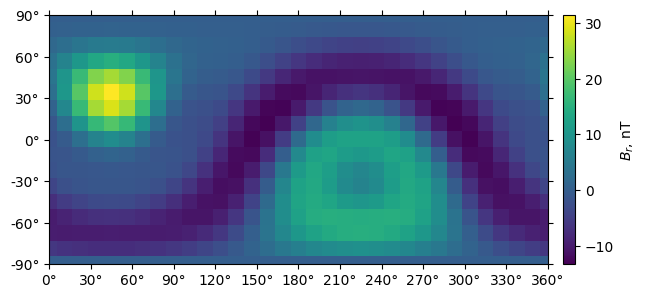

In [26]:
B_r_reconstr.plot_rad()

## SH transformations

In [27]:
def rearrange_gauss_coeffs_to_shtns(gnm, hnm):
    '''
    # Rearrange SH Gauss coefficient arrays to shtns indexed arrays
    # Input parameters:
    #-----------------------
    gnm: SH sine Gauss coefficients of SH degree n and order m 
    hnm: SH cosine Gauss coefficients of SH degree n and order m 
    
    Output values:
    ----------------------
    gnm_shtns: SH sine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    hnm_shtns: SH cosine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    '''
    gnm_w_idx = np.array([gnm,ns,ms]).T
    gnm_shtns = np.array([np.zeros([len(gnm),]), sh.l, sh.m]).T
    hnm_w_idx = np.array([hnm,ns,ms]).T
    hnm_shtns = np.array([np.zeros([len(hnm),]), sh.l, sh.m]).T
    for row in range(gnm_w_idx.shape[0]):
        gnm_shtns[row,0] = gnm_w_idx[np.where(np.all(gnm_shtns[row,1:]==gnm_w_idx[:,1:], axis=1))[0],0]
    for row in range(gnm_w_idx.shape[0]):
        hnm_shtns[row,0] = hnm_w_idx[np.where(np.all(hnm_shtns[row,1:]==hnm_w_idx[:,1:], axis=1))[0],0]
    return gnm_shtns, hnm_shtns

In [28]:
def gauss_to_poloidal(gnm_shtns, hnm_shtns):
    '''
    # Computes the radial, spheroidal and poloidal SH coefficients from the Gauss coefficients of a given magnetic field data referenced at a given radial surface
    # Input parameters:
    #-----------------------
    gnm_shtns: SH sine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    hnm_shtns: SH cosine Gauss coefficients of SH degree n and order m arranged via shtns indexing
    Output values:
    ----------------------
    Qlm radial SHC of degree l and order m arranged via shtns indexing
    Slm spheroidal SHC of degree l and order m arranged via shtns indexing
    Tlm toroidal SHC of degree l and order m arranged via shtns indexing
    '''
    
    Glm = gnm_shtns[:,0] - 1j * hnm_shtns[:,0]
    
    # 3. Initialize SHTns spectral arrays for the vector field
    Qlm = sh.spec_array()  # Radial component
    Slm = sh.spec_array()  # Spheroidal component
    Tlm = sh.spec_array()  # Toroidal component (remains 0 for external potential field)
    
    # 4. Apply Schmidt semi-normalized to Orthonormal correction if needed
    # SHTns provides normalization utilities. If your SHTns instance was 
    # explicitly created with Schmidt norm, N_norm = 1.0.
    # Otherwise, convert Schmidt to Orthonormal:
    N_norm = np.zeros(sh.nlm)
    for i in range(sh.nlm):
        l = sh.l[i]
        m = sh.m[i]
        if l > 0:
            # Standard scaling factor from Schmidt semi-normalized to Orthonormal
            # SHTns default is orthonormal
            N_norm[i] = np.sqrt((2 * l + 1) / (4 * np.pi))

    # 5. Convert to Spheroidal (S_lm) and Radial (Q_lm) coefficients
    # Avoid division by zero at l=0
    valid_l = sh.l > 0
    Slm[valid_l] = (1.0 / sh.l[valid_l]) * N_norm[valid_l] * Glm[valid_l]
    Qlm[valid_l] = sh.l[valid_l] * (sh.l[valid_l] + 1) * Slm[valid_l]
    Tlm[:] = 0.0  # No toroidal component for a potential gradient field

    return Slm, Qlm, Tlm

In [29]:
def define_3d_grid_for_vector_SH_transform(sh, theta_mesh, lambda_mesh, R_eval):
    r = sh.spat_array()  # a spatial array, same as numpy.zeros(sh.spat_shape)
    r[:,:] = R_eval
    t = r.copy()
    t[:, :] = theta_mesh
    l = r.copy()
    l[:, :] = lambda_mesh
    return r, t, l

In [30]:
gnm_shtns, hnm_shtns = rearrange_gauss_coeffs_to_shtns(gnm, hnm)
Slm, Qlm, Tlm = gauss_to_poloidal(gnm_shtns, hnm_shtns)

/tmp/ipykernel_195916/717506432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gnm_shtns[row,0] = gnm_w_idx[np.where(np.all(gnm_shtns[row,1:]==gnm_w_idx[:,1:], axis=1))[0],0]
/tmp/ipykernel_195916/717506432.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hnm_shtns[row,0] = hnm_w_idx[np.where(np.all(hnm_shtns[row,1:]==hnm_w_idx[:,1:], axis=1))[0],0]


In [31]:
theta_arr = np.linspace(0,pi,geom_settings.lat_max)
lambda_arr = np.linspace(0,2*pi,geom_settings.long_max)
theta_mesh, lambda_mesh = np.meshgrid(theta_arr, lambda_arr)
Vr, Vt, Vp = define_3d_grid_for_vector_SH_transform(sh, theta_mesh.T, lambda_mesh.T, geom_settings.R_oc)

In [32]:
# Now (Qlm, Slm, Tlm) represent the vector fields in SHTns
# You can directly synthesize them to a spatial grid:
sh.SHqst_to_spat(Qlm, Slm, Tlm, Vr, Vt, Vp)

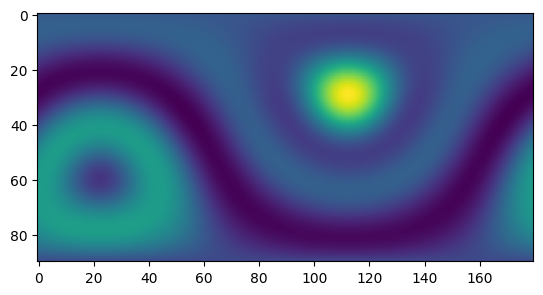

In [33]:
plt.imshow(Vr)

## Globally utilized preallocated arrays

### Gram-Schmidt normalization of the Galerkin base

In [34]:
B_norm_gs_local = torch.zeros([galerkin_repr.band_nr-1, galerkin_repr.band_nr-1, sh_desc.gamma_max]).to(device)

for gamma_two_index in range(1,sh_desc.gamma_max):
    B_norm_gs_local[:,:,gamma_two_index] = normalization_coeffs_gram_schmidt(gamma_two_index, geom_settings.r0, geom_settings.r1, galerkin_repr.resolution, galerkin_repr.band_nr, shtns_cfg.el, shtns_cfg.l2)

B_norm_gs = B_norm_gs_local
del B_norm_gs_local

In [35]:
# ============================================================
# NORMALIZATION
# ============================================================
normalization_mx = derive_normalization_constant_orthonormal(galerkin_repr.band_nr, sh_desc.gamma_max, B_norm_gs) 

# Computing values of the matrix $\mathbf{Psi}_{\gamma}^k(r)$ containing the Galerkin base functions

In [36]:
#TODO: CHECK WHETHER THE SAME RESULT CAN BE OBTAINED FASTER USING THE FULL VECTOR "r_samples" INSTEAD OF single values "r" in the computations
psi_tmp_local = torch.zeros([geom_settings.nr_r_samples, galerkin_repr.band_nr-1, sh_desc.gamma_max]).to(device)
r_ind = 0
for r in geom_settings.r_samples:
    for gamma_two_index in range(1, sh_desc.gamma_max):
        mu = 1 / l2[gamma_two_index]
        psi_tmp_local[r_ind, :, gamma_two_index] = create_vector_of_galerkin_polynomials(mu, gamma_two_index, normalization_mx, galerkin_repr.band_nr, r, shtns_cfg.el)
    r_ind += 1
PSI_MATRIX = psi_tmp_local
del psi_tmp_local

/tmp/ipykernel_195916/1598618823.py:14: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  psi_vec = torch.mul(torch.squeeze(psi_val), torch.squeeze(normalization_mx[:,gamma_two_index].T))


# Computing base function derivatives $\frac{d(\Psi_{\gamma}^k(r))}{dr}$ for the boundary condition:
# $\mu\frac{d(S_{\gamma}(r))}{dr}(r=1) + S_{\gamma}(r=1) = 0$

In [37]:
psi_prime_local = torch.zeros([geom_settings.nr_r_samples, galerkin_repr.band_nr-1, sh_desc.gamma_max]).to(device)
for gamma_two_index in range(1, sh_desc.gamma_max):
    for k in range(galerkin_repr.band_nr-1):
        psi_prime_local[:,k,gamma_two_index] = torch.gradient(PSI_MATRIX[:,k, gamma_two_index])[0]
PSI_PRIME_MX = psi_prime_local
del psi_prime_local

## Computing the discretized spherical laplacian operator $\mathbf{\Delta}=\mathbf{B}^{-1}$ where $B_{ij} = \int_0^1\Psi_i(r)\Psi_j(r)r^2dr $

In [38]:
B_tmp_local = torch.zeros([galerkin_repr.band_nr-1, galerkin_repr.band_nr-1, sh_desc.gamma_max]).to(device)

for gamma_two_index in range(1,sh_desc.gamma_max):
    #print(gamma_two_index, flush=True)
    B_tmp_local[:,:,gamma_two_index] = discretized_laplacian_B_fast(
    gamma_two_index,
    geom_settings.r0,
    geom_settings.r1,
    galerkin_repr.resolution,
    galerkin_repr.band_nr,
    normalization_mx,
    shtns_cfg.el,
    shtns_cfg.l2
)
B_global = B_tmp_local
del B_tmp_local

# Examining the properties of the Elsasser dynamo integral

In [39]:
Elsasser_tmp = torch.zeros([sh_desc.gamma_max+1,sh_desc.beta_max+1], dtype=torch.complex64).to(device)
for gamma_two_index in range(1, sh_desc.gamma_max):
    i = shtns_cfg.el[gamma_two_index]
    j = shtns_cfg.em[gamma_two_index]
    for beta_two_index in list(range(1, sh_desc.beta_max)):
        k = shtns_cfg.el[beta_two_index]
        l = shtns_cfg.em[beta_two_index]
        Elsasser_tmp[gamma_two_index,beta_two_index] = torch.tensor([complex(elsasser(sh_desc.n, sh_desc.m, k, l, i, -j))], dtype=torch.complex64).to(device)

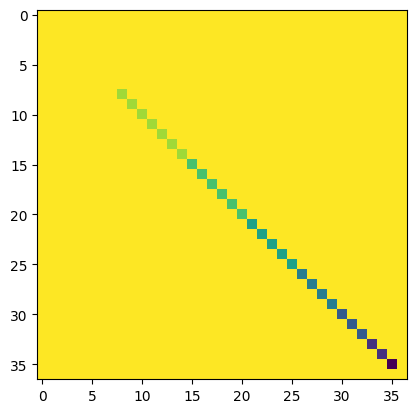

In [40]:
plt.imshow(torch.imag(Elsasser_tmp).cpu().numpy())

## Storing results of the Elsasser dynamo integral $E_{1,\gamma,\beta}^*$ for every SH degree and order 

In [41]:
Elsasser_tmp_for_global = torch.zeros([sh_desc.lmax+1,sh_desc.mmax+1,sh_desc.lmax+1,sh_desc.mmax+1], dtype=torch.complex64).to(device)
for gamma_two_index in range(1, sh_desc.gamma_max):
    i = shtns_cfg.el[gamma_two_index]
    j = shtns_cfg.em[gamma_two_index]
    for beta_two_index in list(range(1, sh_desc.beta_max)):
        k = shtns_cfg.el[beta_two_index]
        l = shtns_cfg.em[beta_two_index]
        Elsasser_tmp_for_global[i,j,k,l] = torch.tensor([complex(elsasser(sh_desc.n, sh_desc.m, k, l, i, -j))], dtype=torch.complex64).to(device)
Elsasser_global = Elsasser_tmp_for_global
del Elsasser_tmp_for_global

In [44]:
bf_arrays = settings.BaseFuncArrays(B_norm_gs=B_norm_gs,
                                    normalization_mx=normalization_mx,
                                    Psi_mx=PSI_MATRIX,
                                    Psi_prime_mx=PSI_PRIME_MX,
                                    Elsasser_mx=Elsasser_global,
                                    B_mx=B_global)

# VALIDATIONS

## Check whether $\mathbf{B}$ is tri-diagonal

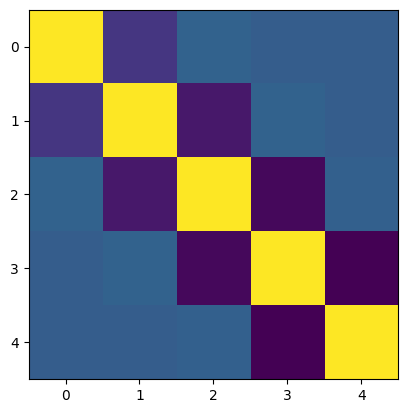

In [46]:
B_show = bf_arrays.B_mx[:,:,1]
plt.imshow(B_show.cpu().numpy())

# Check whether the basis functions form the orthonormal base $\int_0^1\Delta\Psi_i(r)\Psi_j(r)r^2dr = \delta_{ij}$

In [47]:
# ============================================================
# Orthonormal base validation
# ============================================================
def validate_orthogonality(sh_two_index, r0, r1, resolution, band_nr, normalization_mx, el, l2, laplacian):
    mu = 1 / l2[sh_two_index]

    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi(r, el[sh_two_index], band_nr, mu)

    # normalization
    norm = normalization_mx[:, sh_two_index].to(device)
    Psi_vals = Psi_vals * norm[:, None]

    weight = r**2

    # Compute all integrals at once
    Base_product = torch.einsum('ir,jr,r->ij', torch.matmul(laplacian,Psi_vals), Psi_vals, weight) * dr

    return Base_product

In [48]:
laplacian = torch.linalg.inv(bf_arrays.B_mx[:,:,1])

In [49]:
Base_product = torch.zeros([galerkin_repr.band_nr-1, galerkin_repr.band_nr-1, sh_desc.gamma_max]).to(device)
gamma_two_index = 1
Base_product = validate_orthogonality(
gamma_two_index,
geom_settings.r0,
geom_settings.r1,
galerkin_repr.resolution,
galerkin_repr.band_nr,
bf_arrays.normalization_mx,
shtns_cfg.el,
shtns_cfg.l2,
laplacian
)

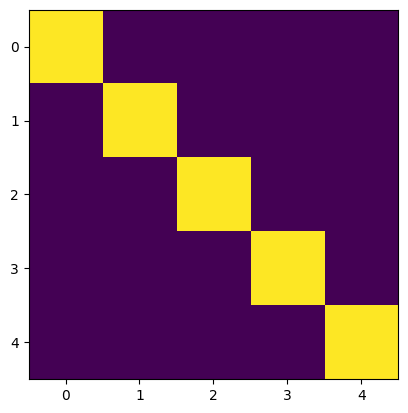

In [50]:
plt.imshow(Base_product.cpu().numpy())

In [51]:
import gc
gc.collect()

510

# SOLVING THE GALERKIN-REPRESENTATION OF THE BG EQUATIONS FOR THE INDUCED POLOIDAL FIELDS

### Calculating source primary field and prescribed azimuthal flow SH coefficients

In [53]:
R_icb = 0 #Later change to: 1.22e6


r_samples_dimensional = np.linspace(R_icb, geom_settings.R_oc, geom_settings.nr_r_samples)
S0_r = torch.zeros([geom_settings.nr_r_samples, sh_desc.gamma_max]).to(device) # torch.zeros([globals()['nr_r_samples'],globals()['gamma_max']]).to(device)
r_ind = 0
for r_ref in r_samples_dimensional:
    gnm, hnm = alldredge_loop_sh_coeffs(ns, ms, sh_desc.lmax, K_loop, alpha_loop, r_loop, theta_loop, phi_loop, r_ref)
    gnm_shtns, hnm_shtns = rearrange_gauss_coeffs_to_shtns(gnm, hnm)
    Slm, Qlm, Tlm = gauss_to_poloidal(gnm_shtns, hnm_shtns)
    S0_r[r_ind, :] = torch.tensor(Slm).to(device)
    r_ind += 1

/tmp/ipykernel_195916/4059247662.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n_degr-1))*(legendre_1/np.sqrt(2*n_degr*(n_degr+1)))
/tmp/ipykernel_195916/4059247662.py:26: RuntimeWarning: divide by zero encountered in divide
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n_degr-1))*(legendre_1/np.sqrt(2*n_degr*(n_degr+1)))
/tmp/ipykernel_195916/4059247662.py:26: RuntimeWarning: invalid value encountered in multiply
  g0n = K*((2*n)/(np.sin(alpha)))*((r/a)**(n_degr-1))*(legendre_1/np.sqrt(2*n_degr*(n_degr+1)))
/tmp/ipykernel_195916/4059247662.py:31: RuntimeWarning: invalid value encountered in multiply
  hnm = g0n*legendre_m*np.sin(m_ord*phi_0)
/tmp/ipykernel_195916/717506432.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gnm_shtns[row,0] = gnm_w_i

In [58]:
t_10 = compute_toroidal_flow_coefficients_vectorized(torch.tensor(geom_settings.r_samples).to(device), torch.tensor(phys_pars.Omega).to(device), torch.tensor(1.0).to(device)) #globals()['R_oc']
t_10 = torch.tensor(t_10, dtype=torch.complex64).to(device)

/tmp/ipykernel_195916/2393074922.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_10 = compute_toroidal_flow_coefficients_vectorized(torch.tensor(geom_settings.r_samples).to(device), torch.tensor(phys_pars.Omega).to(device), torch.tensor(1.0).to(device)) #globals()['R_oc']
/tmp/ipykernel_195916/2393074922.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_10 = torch.tensor(t_10, dtype=torch.complex64).to(device)


## Preallocating block-arrays for solution using the Galerkin-condition $\int_0^1\Psi_{\gamma}^k(r)\epsilon_{\gamma}(r)dr = 0$, where $\epsilon_{\gamma}(r)$ is the residual error of the approximate BG solution.

In [59]:
def rhs_galerkin(psi_matrix, nu_rhs_r, r0, r1, resolution):
    '''
    Evaluates the Galerkin representation of RHS constants in the BG equations
    :param psi_matrix: basis functions
    :param nu_rhs_r: values of constant RHS expressions
    :param r0: lower bound for r
    :param r1: upper bound for r
    :param resolution: domain resolution for the integral expression
    :return: b_gamma Galerkin representation of RHS constants b_gamma(r)
    '''
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    weight = torch.ones(len(r), dtype=torch.complex64).to(device)

    # Compute all integrals at once
    b_gamma = torch.einsum('ir,jr,r->ij', nu_rhs_r, psi_matrix, weight) * dr

    return b_gamma

In [60]:
def derivative_coupling(laplacian, sh_two_index, r0, r1, resolution, band_nr, normalization_mx, l2):
    '''
    Evaluates the Galerkin representation of the laplacian term in the LHS of the BG equations
    :param laplacian: discretized laplacian operator (B^(-1))
    :param degree: SH two-index of the gamma of the induced field
    :param r0: lower bound for r
    :param r1: upper bound for r
    :param resolution: domain resolution for the integral expression
    :return: b_gamma Galerkin representation of RHS constants b_gamma(r)
    '''
    
    mu = 1 / l2[sh_two_index]
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals = compute_all_Psi(r, el[sh_two_index], band_nr, mu)

    # normalization
    norm = normalization_mx[:, sh_two_index].to(device)
    Psi_vals = Psi_vals * norm[:, None]

    weight = torch.ones(len(r)).to(device)

    # Compute all integrals at once
    d_matrix = torch.einsum('ir,jr,r->ij', torch.matmul(laplacian,Psi_vals), Psi_vals, weight) * dr
    return d_matrix

In [64]:
def mass_matrix(gamma_two_index, beta_two_index, r0, r1, resolution, band_nr, normalization_mx, l2):
    '''
    Evaluates the Galerkin representation of the SH coupling term in the LHS of the BG equations
    :param gamma_two_index: SH two-index gamma of the induced field
    :param beta_two_index: SH two-index beta of the induced field
    :param r0: lower bound for r
    :param r1: upper bound for r
    :param resolution: domain resolution for the integral expression
    :param band_nr: polynomial degree of the basis functions
    :param normalization_mx: Graham-Schmidt normalization coeffs
    :param l2: array of SH degree expressions
    :return: b_gamma Galerkin representation of RHS constants b_gamma(r)
    '''
    mu_gamma = 1 / l2[gamma_two_index]
    mu_beta = 1 / l2[beta_two_index]
    r = torch.linspace(r0, r1, resolution, device=device)
    dr = (r1 - r0) / (resolution - 1)

    Psi_vals_gamma = compute_all_Psi(r, el[gamma_two_index], band_nr, mu_gamma)
    Psi_vals_beta = compute_all_Psi(r, el[beta_two_index], band_nr, mu)

    # normalization
    norm = normalization_mx[:, gamma_two_index].to(device)
    Psi_vals_gamma = Psi_vals_gamma * norm[:, None]
    norm = normalization_mx[:, beta_two_index].to(device)
    Psi_vals_beta = Psi_vals_beta * norm[:, None]

    weight = torch.ones(len(r)).to(device)

    # Compute all integrals at once
    mass_matrix = torch.einsum('ir,jr,r->ij', Psi_vals_gamma, Psi_vals_beta, weight) * dr
    return mass_matrix

In [65]:
def boundary_condition_mx_cmb(psi_matrix, psi_prime_matrix, nr_r_samples, gamma_two_index, mu_gamma):
    '''
    Evaluates the Galerkin representation of the boundary conditions applied for each the induced field coeffs of each degree and order
    :param psi_matrix: basis functions
    :param psi_prime_matrix: radial derivatives of basis functions
    :param nr_r_samples: discrete evaluation points at radial distances
    :param gamma_two_index: SH two-index gamma of the induced field
    :param mu_gamma: degree-term multiplier 1/(SH-degree+1)
    :return RHS_cmb - LHS_cmb: deviations from the boundary condition
    '''
    psi_vec = torch.tensor(torch.squeeze(psi_matrix[nr_r_samples-1, :, gamma_two_index]), dtype=torch.double)
    LHS_cmb = psi_vec
    psi_prime_vec = torch.tensor(torch.squeeze(psi_prime_matrix[nr_r_samples-1, :, gamma_two_index]), dtype=torch.double)
    RHS_cmb = - mu_gamma * psi_prime_vec
    return RHS_cmb - LHS_cmb

In [62]:
b_main_eq = torch.empty(0,).to(device)
for gamma_two_index in range(1,sh_desc.gamma_max):
    b_gamma = torch.zeros([1,galerkin_repr.band_nr-1], dtype=torch.complex64).to(device)
    for beta_two_index in range(1,sh_desc.beta_max):
        i = shtns_cfg.el[gamma_two_index]
        j = shtns_cfg.em[gamma_two_index]
        k = shtns_cfg.el[beta_two_index]
        l = shtns_cfg.em[beta_two_index]
        nu_rhs_r = (k * (k + 1)) * t_10 * torch.squeeze(S0_r[:,beta_two_index]) * bf_arrays.Elsasser_mx[i,j,k,l] / (4*torch.pi*i*(i+1))
        nu_rhs_r_k = torch.tile(nu_rhs_r, (galerkin_repr.band_nr,1)).to(device)
        b_gamma += torch.squeeze(torch.diag(rhs_galerkin(torch.tensor(torch.squeeze(bf_arrays.Psi_mx[:,:,gamma_two_index]),dtype=torch.complex64).T, nu_rhs_r_k, r0=0, r1=1, resolution=geom_settings.nr_r_samples)))
    b_main_eq = torch.cat((b_main_eq, b_gamma.T), axis=0)

/tmp/ipykernel_195916/3478837320.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b_gamma += torch.squeeze(torch.diag(rhs_galerkin(torch.tensor(torch.squeeze(bf_arrays.Psi_mx[:,:,gamma_two_index]),dtype=torch.complex64).T, nu_rhs_r_k, r0=0, r1=1, resolution=geom_settings.nr_r_samples)))


In [66]:
shape_mx = torch.empty(0,(galerkin_repr.band_nr-1)*(sh_desc.gamma_max-1)).to(device)
for gamma_two_index in range(1,sh_desc.gamma_max):
    shape_mx_line = torch.empty(galerkin_repr.band_nr-1,0).to(device)
    d_matrix_gamma = derivative_coupling(laplacian, sh_two_index=gamma_two_index, r0=0, r1=1, resolution=galerkin_repr.resolution, band_nr=galerkin_repr.band_nr, normalization_mx=bf_arrays.normalization_mx, l2=shtns_cfg.l2)
    for beta_two_index in range(1,sh_desc.gamma_max):
        m_matrix_gamma_beta = mass_matrix(gamma_two_index=gamma_two_index, beta_two_index=beta_two_index, r0=0, r1=1, resolution=galerkin_repr.resolution, band_nr=galerkin_repr.band_nr, normalization_mx=bf_arrays.normalization_mx, l2=shtns_cfg.l2)
        if gamma_two_index == beta_two_index:
            shape_mx_line = torch.cat((shape_mx_line, d_matrix_gamma - m_matrix_gamma_beta), axis=1)
        else:
            shape_mx_line = torch.cat((shape_mx_line,- m_matrix_gamma_beta), axis=1)
    shape_mx = torch.cat((shape_mx,shape_mx_line), axis=0)

In [67]:
global_LHS_matrix_boundary = torch.zeros(sh_desc.gamma_max-1,(galerkin_repr.band_nr-1)*(sh_desc.gamma_max-1)).to(device)
for gamma_two_index in range(1,sh_desc.gamma_max):
    mu_gamma = 1 / l2[gamma_two_index]
    global_LHS_matrix_boundary[gamma_two_index-1,gamma_two_index*(galerkin_repr.band_nr-1)-(galerkin_repr.band_nr-1):gamma_two_index*(galerkin_repr.band_nr-1)] = boundary_condition_mx_cmb(bf_arrays.Psi_mx, bf_arrays.Psi_prime_mx, geom_settings.nr_r_samples, gamma_two_index, mu_gamma)

/tmp/ipykernel_195916/3011549246.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psi_vec = torch.tensor(torch.squeeze(psi_matrix[nr_r_samples-1, :, gamma_two_index]), dtype=torch.double)
/tmp/ipykernel_195916/3011549246.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psi_prime_vec = torch.tensor(torch.squeeze(psi_prime_matrix[nr_r_samples-1, :, gamma_two_index]), dtype=torch.double)


In [68]:
b_value_boundary_gamma = torch.zeros([(sh_desc.gamma_max-1),]).to(device)

## Assemble and solve the hypermatrix-equation containing the Galerkin-representation and the boundary conditions

In [69]:
total_eq_mx = torch.cat((torch.matmul(shape_mx.T, shape_mx),-global_LHS_matrix_boundary.T), axis=1)

In [70]:
total_eq_mx_line2 = torch.cat((-global_LHS_matrix_boundary,torch.zeros([sh_desc.gamma_max-1,sh_desc.gamma_max-1]).to(device)), axis=1)

In [71]:
total_eq_mx = torch.cat((total_eq_mx, total_eq_mx_line2), axis=0)

In [72]:
b_total_eq = torch.cat((torch.matmul(shape_mx.T,torch.abs(torch.squeeze(b_main_eq))),b_value_boundary_gamma), axis=0)

In [73]:
q = torch.matmul(torch.linalg.inv(total_eq_mx),b_total_eq)

# Reconstruct the induced mf

In [74]:
q_new = torch.tensor(q[:-(b_value_boundary_gamma.shape[0])], dtype=torch.float64)

/tmp/ipykernel_195916/1244058692.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_new = torch.tensor(q[:-(b_value_boundary_gamma.shape[0])], dtype=torch.float64)


In [67]:
S_induced = torch.zeros([geom_settings.nr_r_samples,sh_desc.gamma_max]).to(device)

In [68]:
for gamma_two_index in range(1,sh_desc.gamma_max):
    if gamma_two_index % 10 == 0:
        print(gamma_two_index, flush=True)        
    q_gamma = q_new[gamma_two_index*(galerkin_repr.band_nr-1)-(galerkin_repr.band_nr-1):gamma_two_index*(galerkin_repr.band_nr-1)] #gamma_two_index*globals()['band_nr']-globals()['band_nr']:gamma_two_index*globals()['band_nr']-1
    r_ind = 0
    for r in r_samples:
        psi_vec = create_vector_of_galerkin_polynomials(shtns_cfg.mu, gamma_two_index, bf_arrays.normalization_mx, galerkin_repr.band_nr, r, shtns_cfg.el)
        psi_vec = torch.tensor(psi_vec, dtype=torch.float64)
        sg_val = torch.matmul(psi_vec,q_gamma.T).expand(1,)
        S_induced[r_ind,gamma_two_index-1] = sg_val
        r_ind += 1

/tmp/ipykernel_194004/1832288158.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psi_vec = torch.tensor(psi_vec, dtype=torch.float64)


10
20
30


In [69]:
S_induced_np = S_induced.cpu().numpy()

In [70]:
def define_3d_grid_for_vector_SH_transform(sh, theta_mesh, lambda_mesh):
    r = sh.spat_array()  # a spatial array, same as numpy.zeros(sh.spat_shape)
    r[:,:] = 1#3.48e6
    t = r.copy()
    t[:, :] = theta_mesh
    l = r.copy()
    l[:, :] = lambda_mesh
    return r, t, l

In [71]:
theta_arr = np.linspace(0,pi, geom_settings.lat_max)
lambda_arr = np.linspace(0,2*pi,geom_settings.long_max)
theta_mesh, lambda_mesh = np.meshgrid(theta_arr, lambda_arr)
Vr, Vt, Vp = define_3d_grid_for_vector_SH_transform(sh, theta_mesh.T, lambda_mesh.T)

In [72]:
Qlm_result = np.zeros(sh_desc.gamma_max,).astype(complex)
Tlm_result = np.zeros(sh_desc.gamma_max,).astype(complex)

## Map of induced magnetic field data at depth ...

In [73]:
Slm_result = np.squeeze(S_induced_np[geom_settings.nr_r_samples-1,:]).astype(complex)

In [74]:
# Now (Qlm, Slm, Tlm) represent the vector fields in SHTns
# You can directly synthesize them to a spatial grid:
sh.SHqst_to_spat(Qlm_result, Slm_result, Tlm_result, Vr, Vt, Vp)

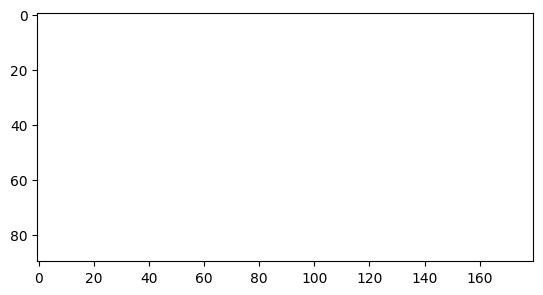

In [75]:
plt.imshow(Vt)